Doeblin's condition holds with n = 2.
  column  BB: min_i P^2(i,BB) = 1.000e-04
  All entries of P^2 positive? False

Stationary distribution pi:
  AAA: 0.0360
   AA: 0.0901
    A: 0.1316
  BBB: 0.1582
   BB: 0.1792
    B: 0.1581
  CCC: 0.1056
   CC: 0.0784
    C: 0.0576
    D: 0.0052

Total variation distance  ||P^n(i,.) - pi||_TV
start       n=2      n=4      n=8     n=10     n=12
  AAA    0.7959   0.7256   0.6732   0.6436   0.6130
   AA    0.7601   0.6681   0.5969   0.5652   0.5351
    A    0.6818   0.5710   0.4605   0.4261   0.3994
  BBB    0.6553   0.5155   0.3744   0.3411   0.3110
   BB    0.6351   0.4982   0.3874   0.3553   0.3249
    B    0.6561   0.5306   0.4293   0.3930   0.3585
  CCC    0.7077   0.6088   0.5029   0.4799   0.4581
   CC    0.7639   0.7082   0.6583   0.6336   0.6096
    C    0.8308   0.7895   0.7086   0.6908   0.6720
    D    0.6827   0.6595   0.6189   0.5986   0.5786


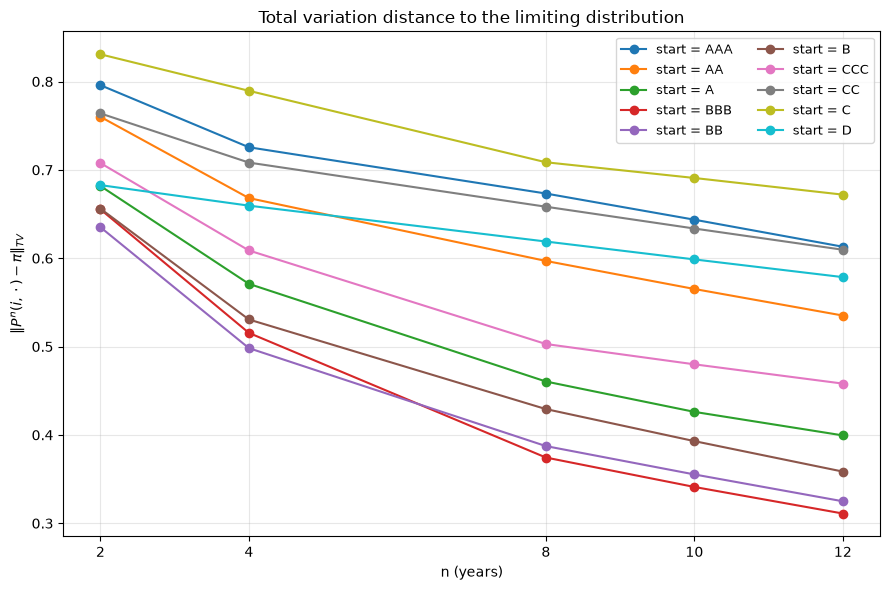

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

states = ["AAA", "AA", "A", "BBB", "BB", "B", "CCC", "CC", "C", "D"]

P = np.array([
    [0.90, 0.06, 0.04, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00],
    [0.04, 0.90, 0.04, 0.02, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00],
    [0.00, 0.04, 0.90, 0.04, 0.02, 0.00, 0.00, 0.00, 0.00, 0.00],
    [0.00, 0.01, 0.04, 0.90, 0.04, 0.01, 0.00, 0.00, 0.00, 0.00],
    [0.00, 0.00, 0.01, 0.04, 0.90, 0.05, 0.00, 0.00, 0.00, 0.00],
    [0.00, 0.00, 0.00, 0.01, 0.05, 0.90, 0.04, 0.00, 0.00, 0.00],
    [0.00, 0.00, 0.00, 0.00, 0.01, 0.04, 0.90, 0.04, 0.01, 0.00],
    [0.00, 0.00, 0.00, 0.00, 0.00, 0.01, 0.04, 0.90, 0.04, 0.01],
    [0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.01, 0.04, 0.90, 0.05],
    [0.00, 0.00, 0.00, 0.00, 0.00, 0.05, 0.10, 0.25, 0.30, 0.30],
])


# ---------- Part (ii): Doeblin's condition ----------

Pn = np.eye(len(states))
for n in range(1, 51):
    Pn = Pn @ P
    positive_cols = np.where((Pn > 0).all(axis=0))[0]
    if len(positive_cols) > 0:
        print(f"Doeblin's condition holds with n = {n}.")
        for j in positive_cols:
            print(f"  column {states[j]:>3}: min_i P^{n}(i,{states[j]}) = {Pn[:, j].min():.3e}")
        print(f"  All entries of P^{n} positive? {(Pn > 0).all()}")
        break

# ---------- Stationary / limiting distribution ----------
eigvals, eigvecs = np.linalg.eig(P.T)
k = np.argmin(np.abs(eigvals - 1))
pi = np.real(eigvecs[:, k])
pi = pi / pi.sum()

print("\nStationary distribution pi:")
for s, p in zip(states, pi):
    print(f"  {s:>3}: {p:.4f}")

# ---------- Part (iv): total variation distance ----------
ns = [2, 4, 8, 10, 12]
tv = np.zeros((len(states), len(ns)))  

for k, n in enumerate(ns):
    Pn = np.linalg.matrix_power(P, n)
    tv[:, k] = 0.5 * np.abs(Pn - pi).sum(axis=1)

print("\nTotal variation distance  ||P^n(i,.) - pi||_TV")
print("start " + "".join(f"{'n='+str(n):>9}" for n in ns))
for i, s in enumerate(states):
    print(f"{s:>5} " + "".join(f"{tv[i, k]:>9.4f}" for k in range(len(ns))))

plt.figure(figsize=(9, 6))
for i, s in enumerate(states):
    plt.plot(ns, tv[i], marker="o", label=f"start = {s}")
plt.xticks(ns)
plt.xlabel("n (years)")
plt.ylabel(r"$\|P^n(i,\cdot) - \pi\|_{TV}$")
plt.title("Total variation distance to the limiting distribution")
plt.legend(ncol=2, fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("credit_tv_distance.png", dpi=150)
plt.show()